In [1]:
import sys
!{sys.executable} -m pip install icrawler Pillow tensorflow scikit-learn matplotlib streamlit pandas jupyterlab

In [2]:
# Cell 1 — All imports
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

print(f"✅ TensorFlow: {tf.__version__}")
print("✅ All imports done!")

✅ TensorFlow: 2.20.0
✅ All imports done!


In [3]:
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(100, 100),      # Skip tiny/bad images
        file_idx_offset='auto'    # Don't overwrite existing images
    )
    time.sleep(2)                 # Small delay between searches

datasets = {
    "motorcycle": [
        ("Royal Enfield Bullet India", 80),
        ("Bajaj Pulsar motorcycle India", 80),
        ("Honda Activa India", 80),
        ("KTM Duke motorcycle India", 60),
    ],
    "pickup_truck": [
        ("Tata Xenon pickup India", 80),
        ("Mahindra Bolero pickup India", 80),
        ("Isuzu D-Max truck India", 80),
        ("Mahindra Pickup truck India", 60),
    ],
    "suv": [
        ("Mahindra Scorpio SUV India", 100),
        ("Hyundai Creta SUV India", 100),
        ("Tata Safari SUV India", 100),
        ("Kia Seltos SUV India", 100),
    ],
    "sedan": [
        ("Maruti Suzuki Dzire sedan", 100),
        ("Honda City sedan India", 100),
        ("Hyundai Verna sedan India", 100),
        ("Tata Tigor sedan India", 100),
    ],
    "hatchback": [
        ("Maruti Swift hatchback India", 100),
        ("Hyundai i20 hatchback India", 100),
        ("Tata Altroz hatchback India", 100),
        ("Volkswagen Polo India", 100),
    ]
}

print(" Starting multi-batch collection...\n")

for class_name, keyword_list in datasets.items():
    print(f"\n📁 {class_name.upper()}")

    # Training images
    for keyword, count in keyword_list:
        print(f"  🔍 Train: '{keyword}' → {count} images")
        scrape_batch(f"dataset/train/{class_name}", keyword, count)

    # Validation images (20% of training keywords)
    for keyword, count in keyword_list[:2]:
        print(f"  🔍 Val:   '{keyword}' → 40 images")
        scrape_batch(f"dataset/validation/{class_name}", keyword, 40)

    print(f"  ✅ {class_name.upper()} done!")

# ── FINAL COUNT ───────────────────────────────────────────────
print("\n Final Dataset Summary:")
print("-" * 45)
grand_total = 0S
for split in ["train", "validation"]:
    for class_name in datasets.keys():
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")
print(f"\n   Grand Total: {grand_total} images")


 Starting multi-batch collection...


📁 MOTORCYCLE
  🔍 Train: 'Royal Enfield Bullet India' → 80 images
  🔍 Train: 'Bajaj Pulsar motorcycle India' → 80 images
  🔍 Train: 'Honda Activa India' → 80 images
  🔍 Train: 'KTM Duke motorcycle India' → 60 images
  🔍 Val:   'Royal Enfield Bullet India' → 40 images
  🔍 Val:   'Bajaj Pulsar motorcycle India' → 40 images
  ✅ MOTORCYCLE done!

📁 PICKUP_TRUCK
  🔍 Train: 'Tata Xenon pickup India' → 80 images
  🔍 Train: 'Mahindra Bolero pickup India' → 80 images
  🔍 Train: 'Isuzu D-Max truck India' → 80 images
  🔍 Train: 'Mahindra Pickup truck India' → 60 images
  🔍 Val:   'Tata Xenon pickup India' → 40 images
  🔍 Val:   'Mahindra Bolero pickup India' → 40 images
  ✅ PICKUP_TRUCK done!

📁 SUV
  🔍 Train: 'Mahindra Scorpio SUV India' → 100 images
  🔍 Train: 'Hyundai Creta SUV India' → 100 images
  🔍 Train: 'Tata Safari SUV India' → 100 images
  🔍 Train: 'Kia Seltos SUV India' → 100 images
  🔍 Val:   'Mahindra Scorpio SUV India' → 40 images
  🔍 Val:   'Hyu

In [4]:
# Top-up block — adds MORE images to existing folders

from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(100, 100),
        file_idx_offset='auto'    # ✅ Adds to existing, no overwrite
    )
    time.sleep(2)

# ── EXTRA KEYWORDS (different from before = fresh images) ─────
topup_datasets = {
    "motorcycle": [
        ("Yamaha FZ motorcycle India", 60),
        ("Hero Splendor motorcycle India", 60),
        ("TVS Apache motorcycle India", 60),
    ],
    "pickup_truck": [
        ("Tata Intra pickup truck India", 60),
        ("Mahindra Supro truck India", 60),
        ("Force Motors pickup India", 60),
    ],
    "suv": [
        ("MG Hector SUV India", 70),
        ("Toyota Fortuner SUV India", 70),
        ("Skoda Kushaq SUV India", 70),
    ],
    "sedan": [
        ("Skoda Slavia sedan India", 70),
        ("Volkswagen Virtus sedan India", 70),
        ("Maruti Ciaz sedan India", 70),
    ],
    "hatchback": [
        ("Maruti Baleno hatchback India", 70),
        ("Honda Jazz hatchback India", 70),
        ("Tata Punch hatchback India", 70),
    ]
}

print("🚀 Topping up existing dataset...\n")

for class_name, keyword_list in topup_datasets.items():
    print(f"\n📁 {class_name.upper()} — adding more images")

    for keyword, count in keyword_list:
        print(f"  🔍 Train: '{keyword}' → {count} images")
        scrape_batch(f"dataset/train/{class_name}", keyword, count)

    # Top up validation too
    for keyword, count in keyword_list[:2]:
        print(f"  🔍 Val:   '{keyword}' → 25 images")
        scrape_batch(f"dataset/validation/{class_name}", keyword, 25)

    print(f"  ✅ {class_name.upper()} topped up!")

# ── FINAL COUNT ───────────────────────────────────────────────
print("\n📊 Updated Dataset Summary:")
print("-" * 45)
grand_total = 0
for split in ["train", "validation"]:
    for class_name in topup_datasets.keys():
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")
print(f"\n  🗂️  Grand Total: {grand_total} images")

🚀 Topping up existing dataset...


📁 MOTORCYCLE — adding more images
  🔍 Train: 'Yamaha FZ motorcycle India' → 60 images
  🔍 Train: 'Hero Splendor motorcycle India' → 60 images
  🔍 Train: 'TVS Apache motorcycle India' → 60 images
  🔍 Val:   'Yamaha FZ motorcycle India' → 25 images
  🔍 Val:   'Hero Splendor motorcycle India' → 25 images
  ✅ MOTORCYCLE topped up!

📁 PICKUP_TRUCK — adding more images
  🔍 Train: 'Tata Intra pickup truck India' → 60 images
  🔍 Train: 'Mahindra Supro truck India' → 60 images
  🔍 Train: 'Force Motors pickup India' → 60 images
  🔍 Val:   'Tata Intra pickup truck India' → 25 images
  🔍 Val:   'Mahindra Supro truck India' → 25 images
  ✅ PICKUP_TRUCK topped up!

📁 SUV — adding more images
  🔍 Train: 'MG Hector SUV India' → 70 images
  🔍 Train: 'Toyota Fortuner SUV India' → 70 images
  🔍 Train: 'Skoda Kushaq SUV India' → 70 images
  🔍 Val:   'MG Hector SUV India' → 25 images
  🔍 Val:   'Toyota Fortuner SUV India' → 25 images
  ✅ SUV topped up!

📁 SEDAN — adding m

In [4]:
# Block 3 — Remove corrupt/bad images
from PIL import Image
import os

CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]

def clean_folder(folder_path):
    removed = 0
    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)
        try:
            img = Image.open(filepath)
            img.verify()
        except Exception:
            os.remove(filepath)
            removed += 1
            print(f"    Removed: {filename}")
    return removed

print("Cleaning dataset...\n")
total_removed = 0

for split in ["train", "validation"]:
    for class_name in CLASSES:
        path = f"dataset/{split}/{class_name}"
        if os.path.exists(path):
            removed = clean_folder(path)
            total_removed += removed
            print(f"   {split}/{class_name} cleaned")

print(f"\n  Total removed: {total_removed} corrupt files")
print(" Dataset is clean and ready for training!")

Cleaning dataset...

   train/motorcycle cleaned
   train/pickup_truck cleaned
   train/suv cleaned
   train/sedan cleaned
   train/hatchback cleaned
   validation/motorcycle cleaned
   validation/pickup_truck cleaned
   validation/suv cleaned
   validation/sedan cleaned
   validation/hatchback cleaned

  Total removed: 0 corrupt files
 Dataset is clean and ready for training!


In [5]:
# image counts 
CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]

print(" Dataset Summary:")
print("-" * 45)
grand_total = 0

for split in ["train", "validation"]:
    for class_name in CLASSES:
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")

print(f"\n Grand Total: {grand_total} images")

 Dataset Summary:
---------------------------------------------
  train        | motorcycle     |  293 images
  train        | pickup_truck   |  373 images
  train        | suv            |  342 images
  train        | sedan          |  313 images
  train        | hatchback      |  382 images
  validation   | motorcycle     |  123 images
  validation   | pickup_truck   |  122 images
  validation   | suv            |  117 images
  validation   | sedan          |  118 images
  validation   | hatchback      |  118 images

 Grand Total: 2301 images


In [6]:
# Block 5 — Set up image data generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"\nClasses found: {train_gen.class_indices}")
print(f" Training batches:   {len(train_gen)}")
print(f" Validation batches: {len(val_gen)}")

Found 1703 images belonging to 5 classes.
Found 598 images belonging to 5 classes.

Classes found: {'hatchback': 0, 'motorcycle': 1, 'pickup_truck': 2, 'sedan': 3, 'suv': 4}
 Training batches:   54
 Validation batches: 19


In [7]:
# Block 6 — Balance unequal class sizes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

print("⚖️  Class Weights:")
print("-" * 35)
for idx, weight in class_weight_dict.items():
    print(f"   {idx_to_class[idx]:14} → {weight:.4f}")

⚖️  Class Weights:
-----------------------------------
   hatchback      → 0.8916
   motorcycle     → 1.1625
   pickup_truck   → 0.9131
   sedan          → 1.0882
   suv            → 0.9959


In [8]:
# Block 7 — Build MobileNetV2 model (stable + works perfectly)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

NUM_CLASSES = 5

#  MobileNetV2 pretrained on ImageNet 
base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze pretrained weights

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\nModel built successfully!")

C:\Users\rahul\AppData\Local\Temp\ipykernel_27756\1383222172.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Model built successfully!


In [9]:
# Block 8 — Train the model
# Safety check before training
if 'model' not in dir():
    print("Model not found! Run Blocks 5, 6, 7 first!")
else:
    print(" Model found! Starting training...")
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs('model', exist_ok=True)

callbacks = [
    # Stops training if no improvement for 6 epochs
    EarlyStopping(
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    # Saves the best model automatically
    ModelCheckpoint(
        'model/car_model.h5',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print("\nTraining complete!")
print(f" Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(" Model saved to model/car_model.h5")

 Model found! Starting training...


C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
41/54 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4094 - loss: 1.6868 

C:\Users\rahul\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4309 - loss: 1.6025 
Epoch 1: val_loss improved from None to 0.68259, saving model to model/car_model.h5


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8180 - loss: 0.4748 - val_accuracy: 0.8946 - val_loss: 0.2683
Epoch 22/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8146 - loss: 0.4639  
Epoch 22: val_loss improved from 0.26825 to 0.26616, saving model to model/car_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8233 - loss: 0.4414 - val_accuracy: 0.9047 - val_loss: 0.2662
Epoch 23/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8309 - loss: 0.4479  
Epoch 23: val_loss improved from 0.26616 to 0.23647, saving model to model/car_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8397 - loss: 0.4138 - val_accuracy: 0.9097 - val_loss: 0.2365
Epoch 24/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8609 - loss: 0.3596  
Epoch 24: val_loss did not improve from 0.23647
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8473 - loss: 0.3942 - val_accuracy: 0.9064 - val_loss: 0.2426
Epoch 25/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8352 - loss: 0.4141    
Epoch 25: val_loss improved from 0.23647 to 0.21815, saving model to model/car_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8473 - loss: 0.3933 - val_accuracy: 0.9231 - val_loss: 0.2181
Epoch 26/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8578 - loss: 0.3733  
Epoch 26: val_loss did not improve from 0.21815
54/54 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8415 - loss: 0.4151 - val_accuracy: 0.9164 - val_loss: 0.2304
Epoch 27/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8558 - loss: 0.3650  
Epoch 27: val_loss did not improve from 0.21815
54/54 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8432 - loss: 0.3830 - val_accuracy: 0.9147 - val_loss: 0.2324
Epoch 28/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8415 - loss: 0.3935  
Epoch 28: val_loss did not improve from 0.21815
54/54 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8280 - loss: 0.4384 - val_accuracy: 0.9214 - val_loss: 0.2365
Epoch 29/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8485 - loss: 0.3812  
Epoch 29: val_loss did not improve from 0.21815


54/54 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8614 - loss: 0.3425 - val_accuracy: 0.9231 - val_loss: 0.2120
Restoring model weights from the end of the best epoch: 30.

Training complete!
 Best val accuracy: 92.31%
 Model saved to model/car_model.h5


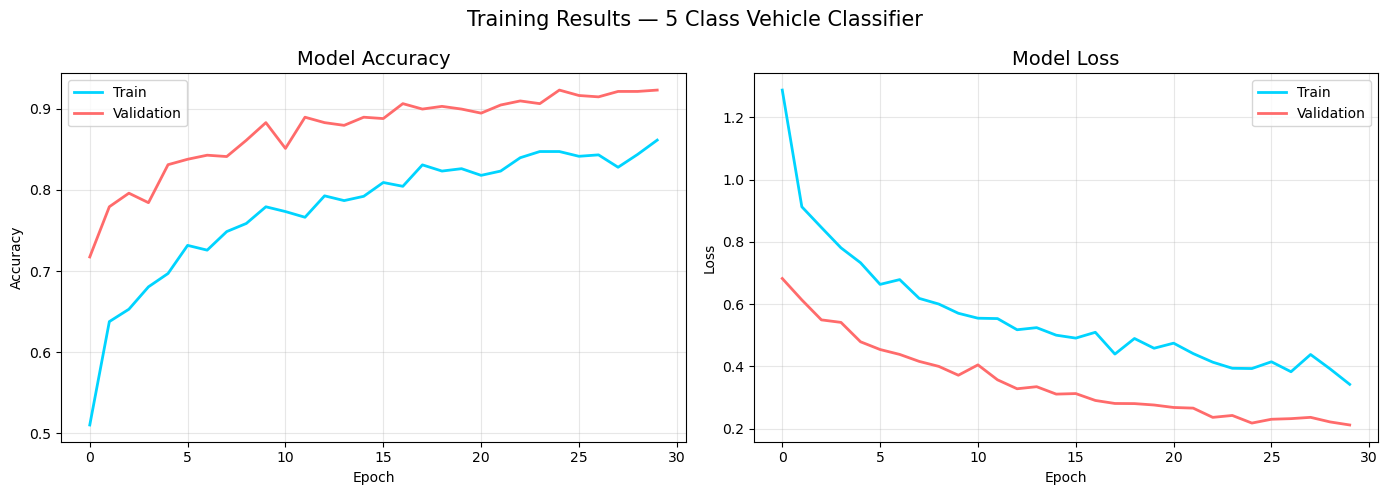


 Final Training Accuracy:   86.14%
 Final Validation Accuracy: 92.31%
 Total Epochs Run:          30


In [10]:
# Block 9 — Visualize training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],
             label='Train', color='#00d4ff', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='#ff6b6b', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],
             label='Train', color='#00d4ff', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation', color='#ff6b6b', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Results — 5 Class Vehicle Classifier', fontsize=15)
plt.tight_layout()
plt.savefig('model/training_results.png')
plt.show()

print(f"\n Final Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f" Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f" Total Epochs Run:          {len(history.history['accuracy'])}")

In [13]:
# Block 9A Proper Fix — Fresh generator for evaluation
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#  CREATE FRESH VALIDATION GENERATOR
fresh_val_datagen = ImageDataGenerator(rescale=1./255)

fresh_val_gen = fresh_val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False          # keeps order consistent
)

# PREDICT 
print(" Running predictions...")
y_pred_probs = model.predict(fresh_val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = fresh_val_gen.classes

class_names = list(fresh_val_gen.class_indices.keys())

print(f"\n Predictions : {len(y_pred)}")
print(f" True labels : {len(y_true)}")
print(f" Classes     : {class_names}")

#  REPORT 
print("\n Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Found 598 images belonging to 5 classes.
 Running predictions...


C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

 Predictions : 598
 True labels : 598
 Classes     : ['hatchback', 'motorcycle', 'pickup_truck', 'sedan', 'suv']

 Classification Report:
              precision    recall  f1-score   support

   hatchback       0.86      0.87      0.87       118
  motorcycle       1.00      0.99      1.00       123
pickup_truck       0.94      0.94      0.94       122
       sedan       0.93      0.86      0.89       118
         suv       0.89      0.95      0.92       117

    accuracy                           0.92       598
   macro avg       0.92      0.92      0.92       598
weighted avg       0.92      0.92      0.92       598



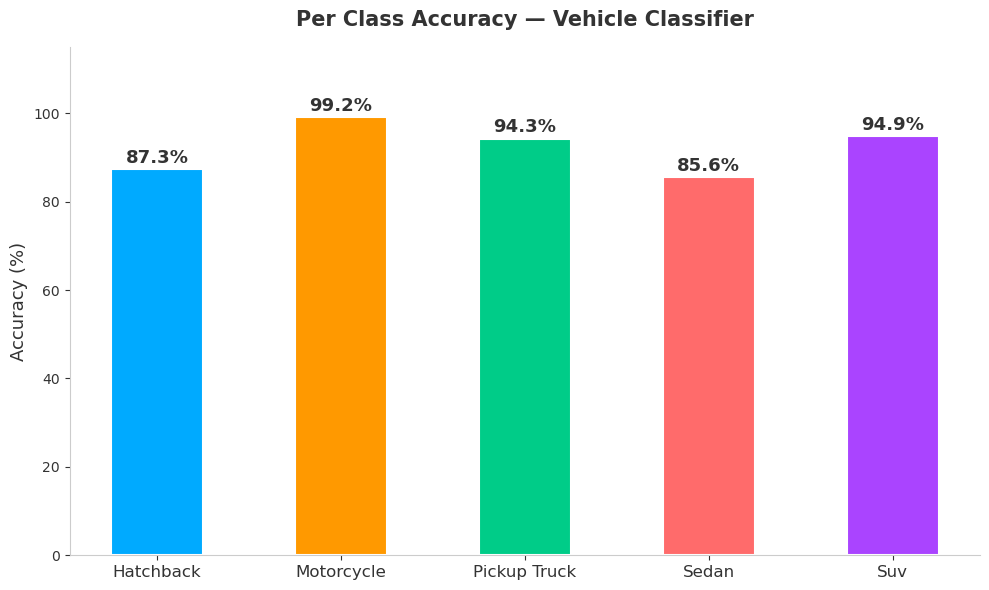


 Per Class Accuracy:
-----------------------------------
  Hatchback       → █████████████████ 87.3%
  Motorcycle      → ███████████████████ 99.2%
  Pickup Truck    → ██████████████████ 94.3%
  Sedan           → █████████████████ 85.6%
  Suv             → ██████████████████ 94.9%


In [17]:
# Block 9B — Per Class Accuracy Bar Chart 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Calculate per class accuracy
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

class_names = list(fresh_val_gen.class_indices.keys())
colors = ['#00aaff', '#ff9900', '#00cc88', '#ff6b6b', '#aa44ff']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    class_names,
    per_class_acc,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add value labels on top of each bar
for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold',
        color='#333333'
    )

# Clean class names on x axis
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(
    [name.replace("_", " ").title() for name in class_names],
    fontsize=12,
    color='#333333'
)

# Styling
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=13, color='#333333')
ax.set_title('Per Class Accuracy — Vehicle Classifier',
             fontsize=15, fontweight='bold',
             color='#333333', pad=15)

# White background
ax.set_facecolor('#ffffff')
fig.patch.set_facecolor('#ffffff')

ax.tick_params(colors='#333333')
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.label.set_color('#333333')

plt.tight_layout()
plt.savefig('model/per_class_accuracy.png',
            facecolor='#ffffff', dpi=150)
plt.show()

# Text summary
print("\n Per Class Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, per_class_acc):
    bar = "█" * int(acc / 5)
    print(f"  {name.replace('_',' ').title():15} → {bar} {acc:.1f}%")

In [18]:
# Block 10 — Save class mapping 
import json
import os

os.makedirs('model', exist_ok=True)

with open('model/class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f)

print(" Class indices saved to model/class_indices.json")
print(f"Mapping: {train_gen.class_indices}")


 Class indices saved to model/class_indices.json
Mapping: {'hatchback': 0, 'motorcycle': 1, 'pickup_truck': 2, 'sedan': 3, 'suv': 4}


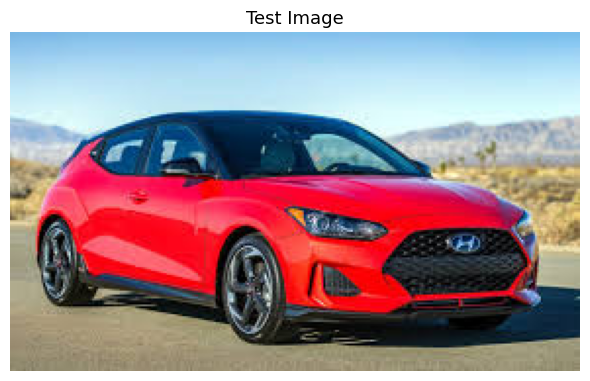

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

  Prediction : Hatchback
  Confidence : 87.41%

All Probabilities:
-----------------------------------
  Hatchback       ██████████████████████████ 87.4%
  Sedan           ███ 12.4%
  SUV              0.2%
  Pickup Truck     0.0%
  Motorcycle       0.0%


In [41]:
# Block 11 Updated 
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image as PILImage

CLASS_DISPLAY = {
    "hatchback":    {"label": "Hatchback"},
    "motorcycle":   {"label": "Motorcycle"},
    "pickup_truck": {"label": "Pickup Truck"},
    "sedan":        {"label": "Sedan"},
    "suv":          {"label": "SUV"},
}

def predict_image(img_path):
    # Load full quality image for display 
    display_img = PILImage.open(img_path).convert("RGB")

    # Show full quality image
    plt.figure(figsize=(6, 5))
    plt.imshow(display_img)
    plt.axis('off')
    plt.title("Test Image", fontsize=13)
    plt.tight_layout()
    plt.show()

    #  Resize only for model prediction
    model_img  = display_img.resize((150, 150))
    img_array  = np.array(model_img) / 255.0
    img_array  = np.expand_dims(img_array, axis=0)

    # ── Predict ───────────────────────────────────────────────
    preds     = model.predict(img_array)[0]
    top_idx   = np.argmax(preds)
    top_class = idx_to_class[top_idx]
    info      = CLASS_DISPLAY[top_class]

    print(f"\n{'='*35}")
    print(f"  Prediction : {info['label']}")
    print(f"  Confidence : {preds[top_idx]*100:.2f}%")
    print(f"{'='*35}")

    print("\nAll Probabilities:")
    print("-" * 35)
    for idx, prob in sorted(enumerate(preds),
                            key=lambda x: x[1], reverse=True):
        cls = idx_to_class[idx]
        d   = CLASS_DISPLAY[cls]
        bar = "█" * int(prob * 30)
        print(f"  {d['label']:15} {bar} {prob*100:.1f}%")

# ── TEST ──────────────────────────────────────────────────────
predict_image("D:/projects/image_classification_1/sd_1.jpg")


In [42]:
# Fix 1 — Scrape more targeted images
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(200, 200),    #  Bigger minimum size
        file_idx_offset='auto'
    )
    time.sleep(2)

# ── MORE TARGETED KEYWORDS ────────────────────────────────────
extra_data = {
    # SUV — clearly boxy tall vehicles
    "suv": [
        ("Mahindra XUV700 side view", 80),
        ("Toyota Fortuner side view India", 80),
        ("Tata Harrier SUV side view", 80),
        ("MG Gloster SUV side view", 80),
        ("Jeep Compass SUV side view India", 80),
    ],
    # Pickup truck — must show cargo bed clearly
    "pickup_truck": [
        ("Isuzu D-Max pickup side view India", 80),
        ("Tata Xenon pickup side view", 80),
        ("Mahindra Scorpio pickup truck", 80),
        ("Toyota Hilux pickup India", 80),
        ("pickup truck cargo bed side view", 80),
    ],
    # Sedan — clearly 3 box design
    "sedan": [
        ("Honda City sedan side view India", 80),
        ("Maruti Dzire sedan side view", 80),
        ("Hyundai Verna side view India", 80),
        ("Toyota Yaris sedan side view", 80),
        ("Skoda Slavia sedan side view", 80),
    ],
    # Hatchback — clearly short rear end
    "hatchback": [
        ("Maruti Swift hatchback side view", 80),
        ("Hyundai i20 side view India", 80),
        ("Tata Altroz side view India", 80),
        ("Honda Jazz side view India", 80),
        ("Maruti Baleno side view India", 80),
    ],
}

print(" Scraping extra targeted images...\n")

for class_name, keyword_list in extra_data.items():
    print(f"\n {class_name.upper()}")
    for keyword, count in keyword_list:
        print(f"  🔍 '{keyword}' → {count} images")
        scrape_batch(
            f"dataset/train/{class_name}",
            keyword, count
        )
    print(f"   {class_name.upper()} done!")

print("\n Extra images collected!")

# CHECK NEW COUNTS 
print("\n Updated Counts:")
print("-" * 40)
for class_name in extra_data.keys():
    path  = f"dataset/train/{class_name}"
    count = len(os.listdir(path))
    print(f"  {class_name:14} → {count} images")

 Scraping extra targeted images...


 SUV
  🔍 'Mahindra XUV700 side view' → 80 images


ERROR:downloader:Response status code 400, file https://www.carandbike.com/_next/image?url=https:%2F%2Fimages.carandbike.com%2Fcar-images%2Fgallery%2Fmahindra%2Fxuv700%2Fexterior%2Fmahindra_xuv_700_sideview.jpg
ERROR:downloader:Response status code 429, file https://emobilityplus.com/wp-content/uploads/2022/02/mahindra-xuv700-in-pictures-take-a-look-at-its-design-features-interior-engines-variants.jpg


  🔍 'Toyota Fortuner side view India' → 80 images


ERROR:downloader:Response status code 403, file https://auto.hindustantimes.com/cms-images/toyota_fortuner/images/exterior_toyota-fortuner_front-left-view_1200x617.jpg


  🔍 'Tata Harrier SUV side view' → 80 images


...

  🔍 'Hyundai i20 side view India' → 80 images


ERROR:downloader:Response status code 403, file https://auto.hindustantimes.com/_next/image?url=https:%2F%2Fimages.hindustantimes.com%2Fauto%2Fimg%2F2020%2F11%2F11%2Foriginal%2FHyundai_i20_9_1605096275074.jpg


  🔍 'Tata Altroz side view India' → 80 images
  🔍 'Honda Jazz side view India' → 80 images


ERROR:downloader:Exception caught when downloading file https://imgd.aeplcdn.com/1056x594/cw/ec/35378/Honda-Jazz-Exterior-131721.jpg, error: HTTPSConnectionPool(host='imgd.aeplcdn.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://imgd.aeplcdn.com/1056x594/cw/ec/39022/Honda-Jazz-Exterior-152329.jpg, error: HTTPSConnectionPool(host='imgd.aeplcdn.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://imgd.aeplcdn.com/0X0/cw/ec/19352/Honda-Jazz-Rear-view-100672.jpg, error: HTTPSConnectionPool(host='imgd.aeplcdn.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://imgd.aeplcdn.com/1056x594/cw/ec/35378/Honda-Jazz-Exterior-131721.jpg, error: HTTPSConnectionPool(host='imgd.aeplcdn.com', port=443): Read timed out. (read timeout=5), remai

  🔍 'Maruti Baleno side view India' → 80 images
   HATCHBACK done!

 Extra images collected!

 Updated Counts:
----------------------------------------
  suv            → 563 images
  pickup_truck   → 692 images
  sedan          → 490 images
  hatchback      → 550 images


In [43]:
# Check updated counts
CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]

print(" Updated Dataset Summary:")
print("-" * 40)
grand_total = 0
for split in ["train", "validation"]:
    for class_name in CLASSES:
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")
print(f"\n    Grand Total: {grand_total} images")

 Updated Dataset Summary:
----------------------------------------
  train        | motorcycle     |  293 images
  train        | pickup_truck   |  692 images
  train        | suv            |  563 images
  train        | sedan          |  490 images
  train        | hatchback      |  550 images
  validation   | motorcycle     |  123 images
  validation   | pickup_truck   |  122 images
  validation   | suv            |  117 images
  validation   | sedan          |  118 images
  validation   | hatchback      |  118 images

    Grand Total: 3186 images


In [44]:
# Top up confused classes
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(200, 200),
        file_idx_offset='auto'
    )
    time.sleep(2)

#  VERY SPECIFIC KEYWORDS 
topup = {
    "suv": [
        ("Mahindra Thar SUV side view", 80),
        ("Toyota Land Cruiser side view India", 80),
        ("Hyundai Tucson SUV side view", 80),
        ("Kia Sonet SUV side view India", 80),
        ("Renault Duster SUV side view", 80),
    ],
    "pickup_truck": [
        ("Mahindra Bolero Camper side view", 80),
        ("Tata Yodha pickup side view", 80),
        ("Ashok Leyland pickup truck India", 80),
        ("Force Gurkha pickup side view", 80),
        ("pickup truck open cargo bed India", 80),
    ],
    "sedan": [
        ("Maruti Suzuki Ciaz sedan side view", 80),
        ("Volkswagen Virtus sedan side view", 80),
        ("Honda Amaze sedan side view India", 80),
        ("Hyundai Aura sedan side view", 80),
        ("Tata Tigor sedan side view India", 80),
    ],
    "hatchback": [
        ("Renault Kwid hatchback side view", 80),
        ("Maruti Celerio hatchback side view", 80),
        ("Datsun Redi-Go hatchback India", 80),
        ("Tata Punch hatchback side view", 80),
        ("Hyundai Grand i10 side view India", 80),
    ],
}

print(" Topping up confused classes...\n")

for class_name, keyword_list in topup.items():
    print(f"\n {class_name.upper()}")
    for keyword, count in keyword_list:
        print(f"   '{keyword}' → {count} images")
        scrape_batch(
            f"dataset/train/{class_name}",
            keyword, count
        )
    # Check new count
    path  = f"dataset/train/{class_name}"
    total = len(os.listdir(path))
    print(f"   {class_name.upper()} now has: {total} images")

print("\n Top up complete!")

#  FINAL COUNT 
print("\nFinal Counts:")
print("-" * 40)
for class_name in ["motorcycle", "pickup_truck",
                   "suv", "sedan", "hatchback"]:
    path  = f"dataset/train/{class_name}"
    count = len(os.listdir(path))
    print(f"  {class_name:14} → {count} images")


 Topping up confused classes...


 SUV
   'Mahindra Thar SUV side view' → 80 images
   'Toyota Land Cruiser side view India' → 80 images


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/toyota-land-cruiser-side-view_Zm1paGaUmZqaraWkpJRnZWdqrWdlZ2c.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/toyota-land-cruiser-side-view_Zm1paGaUmZqaraWkpJRmbmVlrWtlZQ.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/toyota-land-cruiser-side-view_Zm1paGaUmZqaraWkpJRmbmdlrWllZQ.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/toyota-land-cruiser-side-view_Zm1paGaUmZqaraWkpJRma2ttrWdnZw.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/wxl-toyota-land-cruiser-side-view_18431.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/toyota-land-cruiser-side-view_Zm1paGaUmZqaraWkpJRmZmpnrW1raWU.jpg
ERROR:downloader:Response status code 403, file https://images

   'Hyundai Tucson SUV side view' → 80 images


ERROR:downloader:Response status code 400, file https://media.gettyimages.com/id/472711576/photo/hyundai-tucson-compact-suv-front-view.jpg
ERROR:downloader:Response status code 400, file https://media.gettyimages.com/id/510303366/photo/hyundai-tucson-compact-suv-front-view.jpg
ERROR:downloader:Exception caught when downloading file https://cdn.drivek.com/configurator-imgs/cars/it/800/HYUNDAI/TUCSON/44382_SUV-5-DOORS/hyundai-tucson-mhev-back-view.jpg, error: HTTPSConnectionPool(host='cdn.drivek.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://cdn.drivek.com/configurator-imgs/cars/it/800/HYUNDAI/TUCSON/44382_SUV-5-DOORS/hyundai-tucson-mhev-back-view.jpg, error: HTTPSConnectionPool(host='cdn.drivek.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Response status code 521, file https://img.wallpapersafari.com/desktop/1920/1080/10/49/arDjG5.jpg
ERROR:downloa

   'Kia Sonet SUV side view India' → 80 images
   'Renault Duster SUV side view' → 80 images
   SUV now has: 776 images

 PICKUP_TRUCK
   'Mahindra Bolero Camper side view' → 80 images


...

   SEDAN now has: 701 images

 HATCHBACK
   'Renault Kwid hatchback side view' → 80 images
   'Maruti Celerio hatchback side view' → 80 images
   'Datsun Redi-Go hatchback India' → 80 images


ERROR:downloader:Response status code 520, file https://www.team-bhp.com/forum/attachments/indian-car-scene/1486467d1458162979-datsun-redi-go-hatchback-rsz_10485995_822174037911003_8990707152562335456_n1.jpg
ERROR:downloader:Response status code 520, file https://www.team-bhp.com/forum/attachments/indian-car-scene/1513782d1690256186t-datsun-redi-go-hatchback-20160526_145850.jpg
ERROR:downloader:Response status code 520, file https://www.team-bhp.com/forum/attachments/indian-car-scene/1513784d1690256186t-datsun-redi-go-hatchback-20160526_145921.jpg
ERROR:downloader:Response status code 403, file https://i.ndtvimg.com/i/2016-06/datsun-redi-go-launch_827x510_51465281386.jpg


   'Tata Punch hatchback side view' → 80 images
   'Hyundai Grand i10 side view India' → 80 images


ERROR:downloader:Response status code 403, file https://topauto.co.za/wp-content/uploads/2023/06/2023-Hyundai-Grand-i10-sedan.jpg
ERROR:downloader:Response status code 404, file https://www.carmag.co.za/wp-content/uploads/2023/08/g-sedan-4.jpg


   HATCHBACK now has: 806 images

 Top up complete!

Final Counts:
----------------------------------------
  motorcycle     → 293 images
  pickup_truck   → 957 images
  suv            → 776 images
  sedan          → 701 images
  hatchback      → 806 images


In [45]:
# Fix Block 7 — Fine tuning with unfrozen layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

NUM_CLASSES = 5
IMG_SIZE    = (224, 224)   #  Bigger than before
BATCH_SIZE  = 32

# DATA GENERATORS 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f" Classes: {train_gen.class_indices}")
print(f" Train batches: {len(train_gen)}")
print(f" Val batches:   {len(val_gen)}")

#  BUILD MODEL 
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

#  Unfreeze last 30 layers for fine tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

#  Lower learning rate for fine tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n Fine tuning model ready!")

Found 3533 images belonging to 5 classes.
Found 598 images belonging to 5 classes.
 Classes: {'hatchback': 0, 'motorcycle': 1, 'pickup_truck': 2, 'sedan': 3, 'suv': 4}
 Train batches: 111
 Val batches:   19


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 1,890,437 (7.21 MB)

 Non-trainable params: 734,144 (2.80 MB)


 Fine tuning model ready!


In [46]:
# Fix Block 8 — Retrain with class weights
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import os

os.makedirs('model', exist_ok=True)

# Recompute class weights for new data
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

print("⚖️  Class Weights:")
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
for idx, weight in class_weight_dict.items():
    print(f"   {idx_to_class[idx]:14} → {weight:.4f}")

callbacks = [
    EarlyStopping(
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'model/car_model.h5',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n Retraining complete!")
print(f" Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f" Model saved to model/car_model.h5")

⚖️  Class Weights:
   hatchback      → 0.8767
   motorcycle     → 2.4116
   pickup_truck   → 0.7383
   sedan          → 1.0080
   suv            → 0.9106


C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 57/111 ━━━━━━━━━━━━━━━━━━━━ 2:05 2s/step - accuracy: 0.3157 - loss: 1.8820

C:\Users\rahul\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3713 - loss: 1.6558  
Epoch 1: val_loss improved from None to 0.76546, saving model to model/car_model.h5


...

111/111 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9307 - loss: 0.1708 - val_accuracy: 0.9632 - val_loss: 0.1151
Epoch 15/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9405 - loss: 0.1386  
Epoch 15: val_loss improved from 0.11510 to 0.10649, saving model to model/car_model.h5


111/111 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9434 - loss: 0.1339 - val_accuracy: 0.9699 - val_loss: 0.1065
Epoch 16/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9502 - loss: 0.1346  
Epoch 16: val_loss improved from 0.10649 to 0.10460, saving model to model/car_model.h5


111/111 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9479 - loss: 0.1361 - val_accuracy: 0.9632 - val_loss: 0.1046
Epoch 17/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9552 - loss: 0.1123  
Epoch 17: val_loss did not improve from 0.10460
111/111 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9519 - loss: 0.1176 - val_accuracy: 0.9281 - val_loss: 0.2179
Epoch 18/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9534 - loss: 0.1136  
Epoch 18: val_loss improved from 0.10460 to 0.07658, saving model to model/car_model.h5


111/111 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9570 - loss: 0.1111 - val_accuracy: 0.9783 - val_loss: 0.0766
Epoch 19/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9474 - loss: 0.1315  
Epoch 19: val_loss did not improve from 0.07658
111/111 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.9524 - loss: 0.1201 - val_accuracy: 0.9666 - val_loss: 0.1060
Epoch 20/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9700 - loss: 0.0901  
Epoch 20: val_loss did not improve from 0.07658
111/111 ━━━━━━━━━━━━━━━━━━━━ 346s 3s/step - accuracy: 0.9680 - loss: 0.0957 - val_accuracy: 0.9666 - val_loss: 0.0956
Epoch 21/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9724 - loss: 0.0810  
Epoch 21: val_loss did not improve from 0.07658
111/111 ━━━━━━━━━━━━━━━━━━━━ 344s 3s/step - accuracy: 0.9674 - loss: 0.0948 - val_accuracy: 0.9749 - val_loss: 0.0866
Epoch 22/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9616 - loss: 0.1009  
Epoch 22: val_loss improved from

111/111 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9629 - loss: 0.1004 - val_accuracy: 0.9849 - val_loss: 0.0758
Epoch 23/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9629 - loss: 0.0850  
Epoch 23: val_loss did not improve from 0.07585
111/111 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9658 - loss: 0.0838 - val_accuracy: 0.9799 - val_loss: 0.1015
Epoch 24/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9678 - loss: 0.0907  
Epoch 24: val_loss did not improve from 0.07585
111/111 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.9660 - loss: 0.0939 - val_accuracy: 0.9766 - val_loss: 0.0971
Epoch 25/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9581 - loss: 0.1029  
Epoch 25: val_loss did not improve from 0.07585
111/111 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9581 - loss: 0.0990 - val_accuracy: 0.9515 - val_loss: 0.1590
Epoch 26/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9757 - loss: 0.0628  
Epoch 26: val_loss did not impro

In [47]:
# Quick evaluation on new model
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

fresh_val_datagen = ImageDataGenerator(rescale=1./255)
fresh_val_gen = fresh_val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=(224, 224),     # ✅ Updated to 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

y_pred_probs = model.predict(fresh_val_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = fresh_val_gen.classes
class_names  = list(fresh_val_gen.class_indices.keys())
idx_to_class = {v: k for k, v in fresh_val_gen.class_indices.items()}

print("\n Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred,
      target_names=class_names))

Found 598 images belonging to 5 classes.
19/19 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step   

 Classification Report:
              precision    recall  f1-score   support

   hatchback       0.96      0.99      0.97       118
  motorcycle       1.00      1.00      1.00       123
pickup_truck       1.00      0.97      0.98       122
       sedan       0.99      0.97      0.98       118
         suv       0.97      1.00      0.99       117

    accuracy                           0.98       598
   macro avg       0.99      0.98      0.98       598
weighted avg       0.99      0.98      0.98       598



In [4]:
# Better parking/toll plaza scraper
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(200, 200),
        file_idx_offset='auto'
    )
    time.sleep(3)

# ── VERY SPECIFIC PARKING KEYWORDS ────────────────────────────
parking_data = {
    "suv": [
        ("Hyundai Creta parked mall India",      100),
        ("Mahindra XUV parked parking India",    100),
        ("Tata Harrier parked lot India",         100),
        ("SUV parked shopping mall India",        100),
        ("Kia Seltos parked India",              100),
    ],
    "pickup_truck": [
        ("Tata Xenon parked India",              100),
        ("Mahindra pickup parked lot India",     100),
        ("Isuzu pickup parked India",            100),
        ("pickup truck parked mall India",       100),
        ("commercial pickup parked India",       100),
    ],
    "sedan": [
        ("Honda City parked mall India",         100),
        ("Maruti Dzire parked lot India",        100),
        ("Hyundai Verna parked India",           100),
        ("sedan parked shopping mall India",     100),
        ("Skoda Slavia parked India",            100),
    ],
    "hatchback": [
        ("Maruti Swift parked mall India",       100),
        ("Hyundai i20 parked lot India",         100),
        ("Tata Altroz parked India",             100),
        ("hatchback parked shopping mall India", 100),
        ("Maruti Baleno parked India",           100),
    ],
    "motorcycle": [
        ("Royal Enfield parked mall India",      100),
        ("Bajaj Pulsar parked lot India",        100),
        ("motorcycle parked shopping India",     100),
        ("bike parked mall India",               100),
        ("Honda Activa parked India",            100),
    ],
}

print(" Scraping parking images...\n")

for class_name, keyword_list in parking_data.items():
    print(f"\n {class_name.upper()}")
    before = len(os.listdir(f"dataset/train/{class_name}"))

    for keyword, count in keyword_list:
        print(f"   '{keyword}' → {count} images")
        scrape_batch(
            f"dataset/train/{class_name}",
            keyword, count
        )

    after = len(os.listdir(f"dataset/train/{class_name}"))
    print(f"   {before} → {after} (+{after-before} images)")

print("\n Parking scraping complete!")


 Scraping parking images...


 SUV
   'Hyundai Creta parked mall India' → 100 images
   'Mahindra XUV parked parking India' → 100 images
   'Tata Harrier parked lot India' → 100 images
   'SUV parked shopping mall India' → 100 images
   'Kia Seltos parked India' → 100 images
   776 → 1063 (+287 images)

 PICKUP_TRUCK
   'Tata Xenon parked India' → 100 images
   'Mahindra pickup parked lot India' → 100 images
   'Isuzu pickup parked India' → 100 images
   'pickup truck parked mall India' → 100 images
   'commercial pickup parked India' → 100 images
   1329 → 1696 (+367 images)

 SEDAN
   'Honda City parked mall India' → 100 images
   'Maruti Dzire parked lot India' → 100 images
   'Hyundai Verna parked India' → 100 images
   'sedan parked shopping mall India' → 100 images
   'Skoda Slavia parked India' → 100 images
   702 → 993 (+291 images)

 HATCHBACK
   'Maruti Swift parked mall India' → 100 images
   'Hyundai i20 parked lot India' → 100 images
   'Tata Altroz parked India' → 100 ima

In [5]:
# Check current counts after cleaning
CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]

print(" Dataset Summary After Cleaning:")
print("-" * 45)
grand_total = 0

for split in ["train", "validation"]:
    for class_name in CLASSES:
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")

print(f"\n   Grand Total: {grand_total} images")

 Dataset Summary After Cleaning:
---------------------------------------------
  train        | motorcycle     |  633 images
  train        | pickup_truck   | 1243 images
  train        | suv            | 1063 images
  train        | sedan          |  839 images
  train        | hatchback      | 1041 images
  validation   | motorcycle     |  123 images
  validation   | pickup_truck   |  122 images
  validation   | suv            |  117 images
  validation   | sedan          |  118 images
  validation   | hatchback      |  118 images

   Grand Total: 5417 images


In [3]:
# High quality parking + traffic scraper
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(300, 300),   #  Higher minimum size = better quality
        file_idx_offset='auto'
    )
    time.sleep(3)

# ── CAREFULLY CHOSEN KEYWORDS ─────────────────────────────────
# Focus: clear vehicle visible, parking/traffic context
quality_data = {
    "suv": [
        # Parking — clear vehicle visible
        ("Hyundai Creta parked front view India",        60),
        ("Tata Safari parked side view India",           60),
        ("Mahindra XUV700 parked clear view",            60),
        ("Kia Seltos parked showroom India",             60),
        # Traffic — vehicle clearly visible
        ("Hyundai Creta driving road India clear",       60),
        ("Tata Harrier on road clear photo India",       60),
        ("SUV clear photo Indian road daylight",         60),
    ],
    "pickup_truck": [
        # Parking
        ("Tata Xenon pickup parked clear India",         60),
        ("Isuzu D-Max parked side view India",           60),
        ("Mahindra pickup truck parked clear",           60),
        ("pickup truck parked clear daylight India",     60),
        # Traffic
        ("Isuzu D-Max driving road India clear",         60),
        ("Tata Xenon road India clear photo",            60),
        ("pickup truck Indian road clear daylight",      60),
    ],
    "sedan": [
        # Parking
        ("Honda City parked clear side view India",      60),
        ("Maruti Dzire parked clear photo India",        60),
        ("Hyundai Verna parked side view India",         60),
        ("Skoda Slavia parked clear India",              60),
        # Traffic
        ("Honda City driving road India clear",          60),
        ("Maruti Dzire road India clear daylight",       60),
        ("sedan clear photo Indian road daylight",       60),
    ],
    "hatchback": [
        # Parking
        ("Maruti Swift parked clear side view India",    60),
        ("Hyundai i20 parked clear photo India",         60),
        ("Tata Altroz parked side view India",           60),
        ("Maruti Baleno parked clear India",             60),
        # Traffic
        ("Maruti Swift driving road India clear",        60),
        ("Hyundai i20 road India clear daylight",        60),
        ("hatchback clear photo Indian road daylight",   60),
    ],
    "motorcycle": [
        # Parking
        ("Royal Enfield parked clear side view India",   60),
        ("Bajaj Pulsar parked clear photo India",        60),
        ("Honda Activa parked clear India",              60),
        ("TVS Apache parked side view India",            60),
        # Traffic
        ("Royal Enfield riding road India clear",        60),
        ("Bajaj Pulsar road India clear daylight",       60),
        ("motorcycle clear photo Indian road daylight",  60),
    ],
}

# RUN SCRAPER
print(" Scraping high quality parking + traffic images...\n")
print(" Minimum image size: 300x300 (better quality)")
print(" Keywords: specific models + clear + daylight")
print("=" * 55)

for class_name, keyword_list in quality_data.items():
    print(f"\n {class_name.upper()}")
    before = len(os.listdir(f"dataset/train/{class_name}"))

    for keyword, count in keyword_list:
        print(f"  🔍 '{keyword}' → {count} images")
        scrape_batch(
            f"dataset/train/{class_name}",
            keyword, count
        )

    after  = len(os.listdir(f"dataset/train/{class_name}"))
    added  = after - before
    print(f"  ✅ {before} → {after} (+{added} images)")

print("\n" + "=" * 55)
print(" High quality scraping complete!\n")

# ── FINAL COUNT ───────────────────────────────────────────────
print(" Updated Dataset Summary:")
print("-" * 45)
grand_total = 0
for split in ["train", "validation"]:
    for class_name in quality_data.keys():
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")
print(f"\n    Grand Total: {grand_total} images")

 Scraping high quality parking + traffic images...

 Minimum image size: 300x300 (better quality)
 Keywords: specific models + clear + daylight

 SUV
  🔍 'Hyundai Creta parked front view India' → 60 images
  🔍 'Tata Safari parked side view India' → 60 images
  🔍 'Mahindra XUV700 parked clear view' → 60 images
  🔍 'Kia Seltos parked showroom India' → 60 images
  🔍 'Hyundai Creta driving road India clear' → 60 images
  🔍 'Tata Harrier on road clear photo India' → 60 images
  🔍 'SUV clear photo Indian road daylight' → 60 images
  ✅ 1063 → 1321 (+258 images)

 PICKUP_TRUCK
  🔍 'Tata Xenon pickup parked clear India' → 60 images
  🔍 'Isuzu D-Max parked side view India' → 60 images
  🔍 'Mahindra pickup truck parked clear' → 60 images
  🔍 'pickup truck parked clear daylight India' → 60 images
  🔍 'Isuzu D-Max driving road India clear' → 60 images
  🔍 'Tata Xenon road India clear photo' → 60 images
  🔍 'pickup truck Indian road clear daylight' → 60 images
  ✅ 1243 → 1541 (+298 images)

 SEDAN
 

In [4]:
# Check current counts after cleaning
CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]

print(" Dataset Summary After Cleaning:")
print("-" * 45)
grand_total = 0

for split in ["train", "validation"]:
    for class_name in CLASSES:
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")

print(f"\n   Grand Total: {grand_total} images")

 Dataset Summary After Cleaning:
---------------------------------------------
  train        | motorcycle     |  906 images
  train        | pickup_truck   | 1247 images
  train        | suv            | 1167 images
  train        | sedan          |  946 images
  train        | hatchback      | 1225 images
  validation   | motorcycle     |  123 images
  validation   | pickup_truck   |  122 images
  validation   | suv            |  117 images
  validation   | sedan          |  118 images
  validation   | hatchback      |  118 images

   Grand Total: 6089 images


In [5]:
# Multi-view scraper — Side, Front, Rear views
from icrawler.builtin import BingImageCrawler
import os, time

def scrape_batch(folder_path, keyword, count):
    os.makedirs(folder_path, exist_ok=True)
    crawler = BingImageCrawler(
        storage={"root_dir": folder_path},
        log_level=50,
        parser_threads=2,
        downloader_threads=4
    )
    crawler.crawl(
        keyword=keyword,
        max_num=count,
        min_size=(300, 300),
        file_idx_offset='auto'
    )
    time.sleep(3)

# ── 500 IMAGES PER CLASS ──────────────────────────────────────
# Each class = ~170 side + ~165 front + ~165 rear = 500
multiview_data = {
    "suv": [
        # Side view (~170)
        ("Hyundai Creta side view clear India",          60),
        ("Mahindra XUV700 side view India",              60),
        ("Tata Safari side view clear India",            50),
        # Front view (~165)
        ("Hyundai Creta front view clear India",         55),
        ("Kia Seltos front view India",                  55),
        ("Tata Harrier front view India",                55),
        # Rear view (~165)
        ("Hyundai Creta rear view clear India",          55),
        ("Mahindra Scorpio rear view India",             55),
        ("Toyota Fortuner rear view India",              55),
    ],
    "pickup_truck": [
        # Side view (~170)
        ("Tata Xenon side view clear India",             60),
        ("Isuzu D-Max side view India",                  60),
        ("Mahindra pickup side view India",              50),
        # Front view (~165)
        ("Tata Xenon front view India",                  55),
        ("Isuzu D-Max front view India",                 55),
        ("Mahindra Bolero pickup front view",            55),
        # Rear view (~165)
        ("Tata Xenon rear view India",                   55),
        ("Isuzu D-Max rear view India",                  55),
        ("pickup truck rear view India clear",           55),
    ],
    "sedan": [
        # Side view (~170)
        ("Honda City side view clear India",             60),
        ("Maruti Dzire side view India",                 60),
        ("Hyundai Verna side view India",                50),
        # Front view (~165)
        ("Honda City front view India",                  55),
        ("Skoda Slavia front view India",                55),
        ("Volkswagen Virtus front view India",           55),
        # Rear view (~165)
        ("Honda City rear view India",                   55),
        ("Maruti Dzire rear view India",                 55),
        ("Hyundai Verna rear view India",                55),
    ],
    "hatchback": [
        # Side view (~170)
        ("Maruti Swift side view clear India",           60),
        ("Hyundai i20 side view India",                  60),
        ("Tata Altroz side view India",                  50),
        # Front view (~165)
        ("Maruti Swift front view India",                55),
        ("Hyundai i20 front view India",                 55),
        ("Maruti Baleno front view India",               55),
        # Rear view (~165)
        ("Maruti Swift rear view India",                 55),
        ("Hyundai i20 rear view India",                  55),
        ("Tata Altroz rear view India",                  55),
    ],
    "motorcycle": [
        # Side view (~170)
        ("Royal Enfield side view clear India",          60),
        ("Bajaj Pulsar side view India",                 60),
        ("Honda Activa side view India",                 50),
        # Front view (~165)
        ("Royal Enfield front view India",               55),
        ("Bajaj Pulsar front view India",                55),
        ("TVS Apache front view India",                  55),
        # Rear view (~165)
        ("Royal Enfield rear view India",                55),
        ("Bajaj Pulsar rear view India",                 55),
        ("Yamaha FZ rear view India",                    55),
    ],
}

# ── RUN SCRAPER ───────────────────────────────────────────────
print(" Scraping multi-view images...\n")
print(" Views    : Side + Front + Rear")
print(" Target   : ~500 new images per class")
print(" Min size : 300x300 (good quality)")
print("=" * 55)

for class_name, keyword_list in multiview_data.items():
    print(f"\n {class_name.upper()}")
    before = len(os.listdir(f"dataset/train/{class_name}"))
    print(f"  Current: {before} images")

    for keyword, count in keyword_list:
        print(f"   '{keyword}' → {count} images")
        scrape_batch(
            f"dataset/train/{class_name}",
            keyword, count
        )

    after = len(os.listdir(f"dataset/train/{class_name}"))
    added = after - before
    print(f"   {before} → {after} (+{added} new images)")

print("\n" + "=" * 55)
print(" Multi-view scraping complete!\n")

# ── FINAL SUMMARY ─────────────────────────────────────────────
print(" Final Dataset Summary:")
print("-" * 45)
grand_total = 0
for split in ["train", "validation"]:
    for class_name in multiview_data.keys():
        path  = f"dataset/{split}/{class_name}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        grand_total += count
        print(f"  {split:12} | {class_name:14} | {count:4} images")
print(f"\n    Grand Total: {grand_total} images")

 Scraping multi-view images...

 Views    : Side + Front + Rear
 Target   : ~500 new images per class
 Min size : 300x300 (good quality)

 SUV
  Current: 1167 images
   'Hyundai Creta side view clear India' → 60 images
   'Mahindra XUV700 side view India' → 60 images
   'Tata Safari side view clear India' → 50 images
   'Hyundai Creta front view clear India' → 55 images
   'Kia Seltos front view India' → 55 images
   'Tata Harrier front view India' → 55 images
   'Hyundai Creta rear view clear India' → 55 images
   'Mahindra Scorpio rear view India' → 55 images
   'Toyota Fortuner rear view India' → 55 images
   1167 → 1416 (+249 new images)

 PICKUP_TRUCK
  Current: 1247 images
   'Tata Xenon side view clear India' → 60 images
   'Isuzu D-Max side view India' → 60 images
   'Mahindra pickup side view India' → 50 images
   'Tata Xenon front view India' → 55 images
   'Isuzu D-Max front view India' → 55 images
   'Mahindra Bolero pickup front view' → 55 images
   'Tata Xenon rear view I

In [6]:
# Quick count check
CLASSES = ["motorcycle", "pickup_truck", "suv", "sedan", "hatchback"]
print(" Final Counts:")
print("-" * 40)
for class_name in CLASSES:
    path  = f"dataset/train/{class_name}"
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  {class_name:14} → {count} images")

 Final Counts:
----------------------------------------
  motorcycle     → 1054 images
  pickup_truck   → 1605 images
  suv            → 1387 images
  sedan          → 1156 images
  hatchback      → 1400 images


In [1]:
# Fix Keras version for EfficientNet
import sys
!{sys.executable} -m pip install tensorflow==2.12.0 keras==2.12.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [3]:
# Check your exact versions
import tensorflow as tf
import keras
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

TensorFlow : 2.20.0
Keras      : 3.11.3


In [4]:
# EfficientNetV2B3 — compatible with Keras 3.x
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

NUM_CLASSES = 5
IMG_SIZE    = (300, 300)
BATCH_SIZE  = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.5, 1.5],
    channel_shift_range=30.0
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f" Classes      : {train_gen.class_indices}")
print(f" Train batches: {len(train_gen)}")
print(f" Val batches  : {len(val_gen)}")

# ── BUILD EfficientNetV2B3 ────────────────────────────────────
base_model = EfficientNetV2B3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n EfficientNetV2B3 loaded successfully!")

Found 6602 images belonging to 5 classes.
Found 598 images belonging to 5 classes.
 Classes      : {'hatchback': 0, 'motorcycle': 1, 'pickup_truck': 2, 'sedan': 3, 'suv': 4}
 Train batches: 207
 Val batches  : 19
52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)       │ (None, 10, 10, 1536)        │      12,930,622 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1536)                │           6,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         786,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,856,323 (52.86 MB)

 Trainable params: 2,611,065 (9.96 MB)

 Non-trainable params: 11,245,258 (42.90 MB)


 EfficientNetV2B3 loaded successfully!


In [3]:
# Cell 2 — Build EfficientNetV2B3 with correct preprocessing
NUM_CLASSES = 5
IMG_SIZE    = (300, 300)
BATCH_SIZE  = 32

# ✅ Correct preprocessing for EfficientNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f" Classes      : {train_gen.class_indices}")
print(f" Train batches: {len(train_gen)}")
print(f" Val batches  : {len(val_gen)}")

# ── BUILD MODEL ───────────────────────────────────────────────
base_model = EfficientNetV2B3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze for Phase 1

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n Model ready!")

Found 6602 images belonging to 5 classes.
Found 598 images belonging to 5 classes.
 Classes      : {'hatchback': 0, 'motorcycle': 1, 'pickup_truck': 2, 'sedan': 3, 'suv': 4}
 Train batches: 207
 Val batches  : 19


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-b3 (Functional)       │ (None, 10, 10, 1536)        │      12,930,622 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1536)                │           6,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         393,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,331,523 (50.86 MB)

 Trainable params: 397,829 (1.52 MB)

 Non-trainable params: 12,933,694 (49.34 MB)


 Model ready!


In [4]:
# Cell 3 — Full 2 phase training
os.makedirs('model', exist_ok=True)

# Class weights
labels        = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
idx_to_class      = {v: k for k, v in train_gen.class_indices.items()}

print(" Class Weights:")
for idx, weight in class_weight_dict.items():
    print(f"   {idx_to_class[idx]:14} → {weight:.4f}")

# ── PHASE 1 ───────────────────────────────────────────────────
print("\n Phase 1 — Training top layers (frozen base)...")
print("   Expected accuracy → 85-90%")
print("   Expected time     → 30-45 mins\n")

history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(patience=5,
                      restore_best_weights=True,
                      verbose=1),
        ModelCheckpoint('model/car_model.h5',
                        save_best_only=True,
                        verbose=1)
    ]
)

phase1_acc = max(history1.history['val_accuracy']) * 100
print(f"\n Phase 1 complete → {phase1_acc:.2f}%")

# ── PHASE 2 ───────────────────────────────────────────────────
print("\n🔧 Phase 2 — Fine tuning last 30 layers...")
print("   Expected accuracy → 97-99%")
print("   Expected time     → 60-90 mins\n")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(patience=6,
                      restore_best_weights=True,
                      verbose=1),
        ModelCheckpoint('model/car_model.h5',
                        save_best_only=True,
                        verbose=1)
    ]
)

phase2_acc = max(history2.history['val_accuracy']) * 100
best_acc   = max(phase1_acc, phase2_acc)

print(f"\n{'='*40}")
print(f" Phase 1 accuracy : {phase1_acc:.2f}%")
print(f" Phase 2 accuracy : {phase2_acc:.2f}%")
print(f" Best accuracy    : {best_acc:.2f}%")
print(f" Model saved → model/car_model.h5")
print(f"{'='*40}")

 Class Weights:
   hatchback      → 0.9431
   motorcycle     → 1.2528
   pickup_truck   → 0.8227
   sedan          → 1.1422
   suv            → 0.9520

 Phase 1 — Training top layers (frozen base)...
   Expected accuracy → 85-90%
   Expected time     → 30-45 mins



C:\Users\rahul\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
172/207 ━━━━━━━━━━━━━━━━━━━━ 2:41 5s/step - accuracy: 0.6006 - loss: 1.1042 

C:\Users\rahul\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6110 - loss: 1.0696  
Epoch 1: val_loss improved from None to 0.41425, saving model to model/car_model.h5


...

207/207 ━━━━━━━━━━━━━━━━━━━━ 1088s 5s/step - accuracy: 0.9452 - loss: 0.1572 - val_accuracy: 0.9866 - val_loss: 0.0503
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9489 - loss: 0.1361   
Epoch 8: val_loss did not improve from 0.05031
207/207 ━━━━━━━━━━━━━━━━━━━━ 1069s 5s/step - accuracy: 0.9435 - loss: 0.1451 - val_accuracy: 0.9849 - val_loss: 0.0573
Epoch 9/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9502 - loss: 0.1334   
Epoch 9: val_loss did not improve from 0.05031
207/207 ━━━━━━━━━━━━━━━━━━━━ 1057s 5s/step - accuracy: 0.9490 - loss: 0.1358 - val_accuracy: 0.9799 - val_loss: 0.0622
Epoch 10/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9529 - loss: 0.1254   
Epoch 10: val_loss did not improve from 0.05031
207/207 ━━━━━━━━━━━━━━━━━━━━ 1066s 5s/step - accuracy: 0.9508 - loss: 0.1275 - val_accuracy: 0.9833 - val_loss: 0.0574
Epoch 11/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9579 - loss: 0.1189   
Epoch 11: val_loss did not i

207/207 ━━━━━━━━━━━━━━━━━━━━ 1043s 5s/step - accuracy: 0.9594 - loss: 0.1081 - val_accuracy: 0.9866 - val_loss: 0.0502
Epoch 14/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9665 - loss: 0.0995   
Epoch 14: val_loss did not improve from 0.05016
207/207 ━━━━━━━━━━━━━━━━━━━━ 1042s 5s/step - accuracy: 0.9641 - loss: 0.1025 - val_accuracy: 0.9883 - val_loss: 0.0519
Epoch 15/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9665 - loss: 0.0884   
Epoch 15: val_loss did not improve from 0.05016
207/207 ━━━━━━━━━━━━━━━━━━━━ 1045s 5s/step - accuracy: 0.9662 - loss: 0.0898 - val_accuracy: 0.9849 - val_loss: 0.0594
Epoch 16/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9752 - loss: 0.0711   
Epoch 16: val_loss improved from 0.05016 to 0.04865, saving model to model/car_model.h5


207/207 ━━━━━━━━━━━━━━━━━━━━ 1045s 5s/step - accuracy: 0.9729 - loss: 0.0773 - val_accuracy: 0.9900 - val_loss: 0.0486
Epoch 17/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9675 - loss: 0.0910   
Epoch 17: val_loss improved from 0.04865 to 0.04103, saving model to model/car_model.h5


207/207 ━━━━━━━━━━━━━━━━━━━━ 1106s 5s/step - accuracy: 0.9696 - loss: 0.0867 - val_accuracy: 0.9916 - val_loss: 0.0410
Epoch 18/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9700 - loss: 0.0803   
Epoch 18: val_loss did not improve from 0.04103
207/207 ━━━━━━━━━━━━━━━━━━━━ 1042s 5s/step - accuracy: 0.9703 - loss: 0.0797 - val_accuracy: 0.9900 - val_loss: 0.0437
Epoch 19/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9677 - loss: 0.0834   
Epoch 19: val_loss did not improve from 0.04103
207/207 ━━━━━━━━━━━━━━━━━━━━ 1063s 5s/step - accuracy: 0.9685 - loss: 0.0843 - val_accuracy: 0.9900 - val_loss: 0.0427
Epoch 20/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9685 - loss: 0.0823   
Epoch 20: val_loss improved from 0.04103 to 0.03460, saving model to model/car_model.h5


207/207 ━━━━━━━━━━━━━━━━━━━━ 1121s 5s/step - accuracy: 0.9696 - loss: 0.0827 - val_accuracy: 0.9933 - val_loss: 0.0346
Restoring model weights from the end of the best epoch: 20.

 Phase 1 accuracy : 95.48%
 Phase 2 accuracy : 99.33%
 Best accuracy    : 99.33%
 Model saved → model/car_model.h5


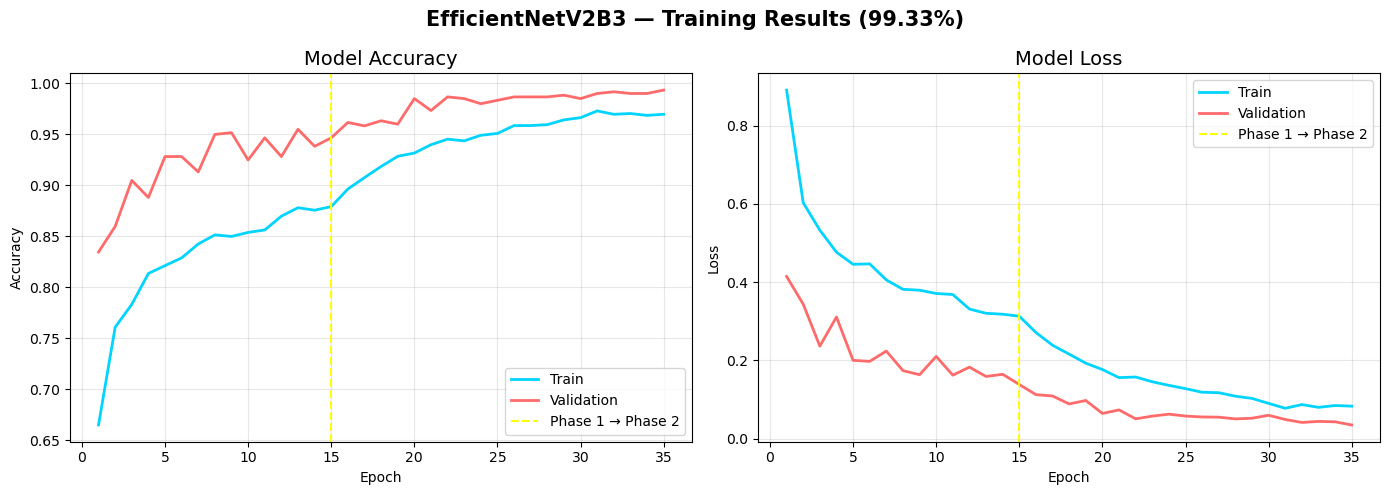

 Phase 1 epochs : 15
 Phase 2 epochs : 20
 Total epochs   : 35
 Best accuracy  : 99.33%


In [5]:
# Accuracy & Loss plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Combine Phase 1 + Phase 2 history ────────────────────────
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
epochs  = range(1, len(acc) + 1)

# Phase 1 end point for vertical line
phase1_end = len(history1.history['accuracy'])

# ── Accuracy Plot ─────────────────────────────────────────────
axes[0].plot(epochs, acc,     label='Train',
             color='#00d4ff', linewidth=2)
axes[0].plot(epochs, val_acc, label='Validation',
             color='#ff6b6b', linewidth=2)
axes[0].axvline(x=phase1_end, color='#ffff00',
                linestyle='--', linewidth=1.5,
                label='Phase 1 → Phase 2')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss Plot ─────────────────────────────────────────────────
axes[1].plot(epochs, loss,     label='Train',
             color='#00d4ff', linewidth=2)
axes[1].plot(epochs, val_loss, label='Validation',
             color='#ff6b6b', linewidth=2)
axes[1].axvline(x=phase1_end, color='#ffff00',
                linestyle='--', linewidth=1.5,
                label='Phase 1 → Phase 2')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'EfficientNetV2B3 — Training Results (99.33%)',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig('model/training_results.png', dpi=150)
plt.show()

print(f" Phase 1 epochs : {phase1_end}")
print(f" Phase 2 epochs : {len(history2.history['accuracy'])}")
print(f" Total epochs   : {len(acc)}")
print(f" Best accuracy  : {max(val_acc)*100:.2f}%")

In [6]:
# Classification report
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

fresh_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
fresh_val_gen = fresh_val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    shuffle=False              # ✅ Important!
)

print(" Running predictions...")
y_pred_probs = model.predict(fresh_val_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = fresh_val_gen.classes
class_names  = list(fresh_val_gen.class_indices.keys())
idx_to_class = {v: k for k, v in fresh_val_gen.class_indices.items()}

print("\n Classification Report:")
print("=" * 60)
print(classification_report(
    y_true, y_pred,
    target_names=class_names
))

Found 598 images belonging to 5 classes.
 Running predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step  

 Classification Report:
              precision    recall  f1-score   support

   hatchback       0.99      1.00      1.00       118
  motorcycle       1.00      1.00      1.00       123
pickup_truck       0.99      1.00      1.00       122
       sedan       1.00      0.97      0.98       118
         suv       0.98      1.00      0.99       117

    accuracy                           0.99       598
   macro avg       0.99      0.99      0.99       598
weighted avg       0.99      0.99      0.99       598



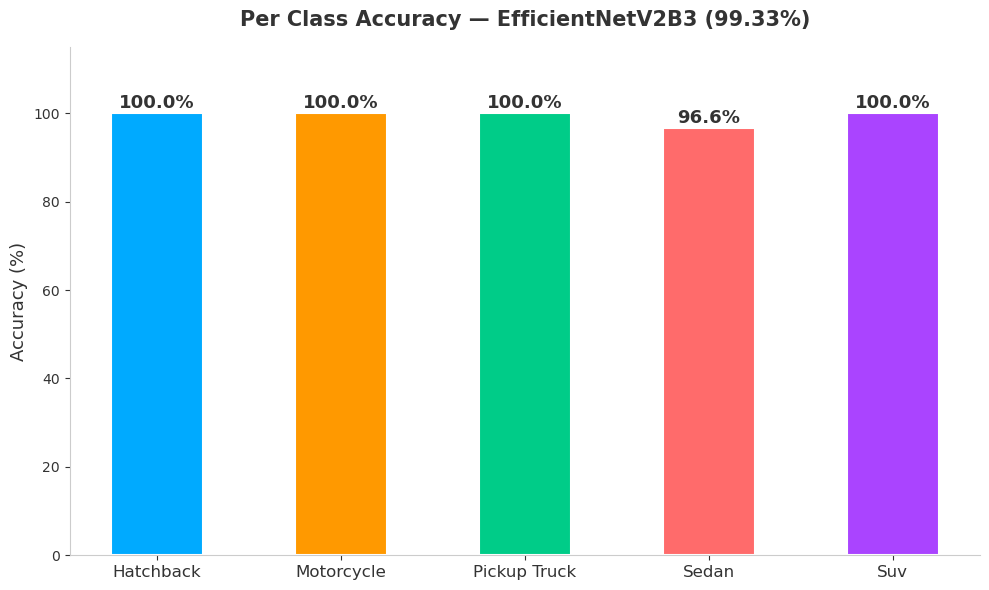


 Per Class Accuracy:
-----------------------------------
  Hatchback       → ████████████████████ 100.0%
  Motorcycle      → ████████████████████ 100.0%
  Pickup Truck    → ████████████████████ 100.0%
  Sedan           → ███████████████████ 96.6%
  Suv             → ████████████████████ 100.0%


In [7]:
# Per class accuracy bar chart
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm            = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
class_names   = list(fresh_val_gen.class_indices.keys())
colors        = ['#00aaff', '#ff9900', '#00cc88', '#ff6b6b', '#aa44ff']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    class_names,
    per_class_acc,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Value labels on bars
for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold',
        color='#333333'
    )

# Clean class names
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(
    [name.replace("_", " ").title() for name in class_names],
    fontsize=12, color='#333333'
)

# Styling
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=13, color='#333333')
ax.set_title(
    'Per Class Accuracy — EfficientNetV2B3 (99.33%)',
    fontsize=15, fontweight='bold',
    color='#333333', pad=15
)
ax.set_facecolor('#ffffff')
fig.patch.set_facecolor('#ffffff')
ax.tick_params(colors='#333333')
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model/per_class_accuracy.png',
            facecolor='#ffffff', dpi=150)
plt.show()

# Text summary
print("\n Per Class Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, per_class_acc):
    bar = "█" * int(acc / 5)
    print(f"  {name.replace('_',' ').title():15} → {bar} {acc:.1f}%")

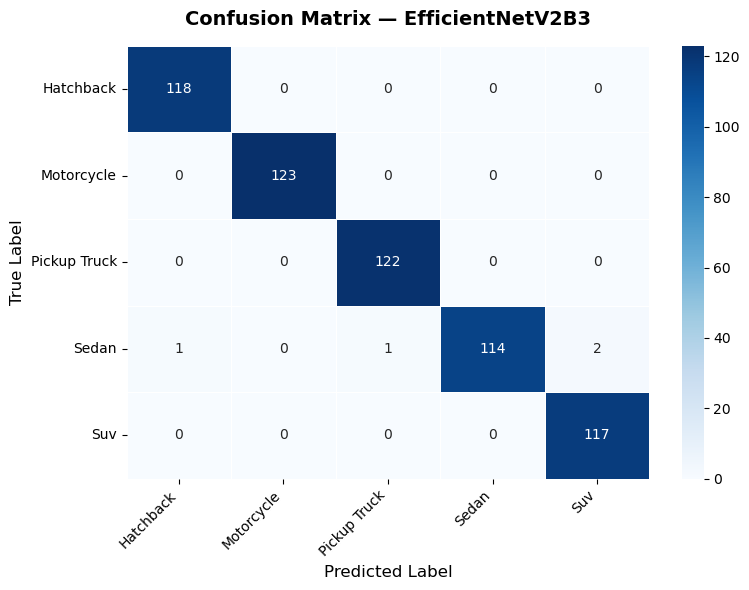


 Confusion Matrix saved!
Rows = True labels
Cols = Predicted labels
Diagonal = Correct predictions 


In [8]:
# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm          = confusion_matrix(y_true, y_pred)
class_names = [name.replace('_',' ').title()
               for name in fresh_val_gen.class_indices.keys()]

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5
)

ax.set_title(
    'Confusion Matrix — EfficientNetV2B3',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('model/confusion_matrix.png', dpi=150)
plt.show()

print("\n Confusion Matrix saved!")
print("Rows = True labels")
print("Cols = Predicted labels")
print("Diagonal = Correct predictions ")